In [1]:
import csv
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import random

from collections import Counter

# Allowed for balancing only, per assignment
from imblearn.over_sampling import SMOTE

In [2]:
# =========================
# Activation functions
# =========================

def logistic(x, a=1.0, derivative=False):
    y = 1.0 / (1.0 + np.exp(-a * x))
    if derivative:
        return a * y * (1.0 - y)
    return y

def tanh_act(x, a=1.716, b=2/3, derivative=False):
    y = a * np.tanh(b * x)
    if derivative:
        return a * b * (1.0 - np.tanh(b * x) ** 2)
    return y

def leaky_relu(x, pos_slope=1.0, neg_slope=0.01, derivative=False):
    if derivative:
        grad = np.ones_like(x) * pos_slope
        grad[x < 0] = neg_slope
        return grad
    return np.where(x >= 0, pos_slope * x, neg_slope * x)

ACTIVATIONS = {
    "logistic": logistic,
    "tanh": tanh_act,
    "leaky_relu": leaky_relu
}

In [3]:
# =========================
# Utility functions
# =========================

def one_hot_encode(y, num_classes=8):
    """
    Expects y labels in {1,...,8}
    Returns shape (N, num_classes)
    """
    y = np.asarray(y).astype(int).reshape(-1)
    oh = np.zeros((len(y), num_classes), dtype=np.float64)
    oh[np.arange(len(y)), y - 1] = 1.0
    return oh

def decode_one_hot(y_onehot):
    """
    Converts network outputs or one-hot rows to labels {1,...,8}
    """
    return np.argmax(y_onehot, axis=1) + 1

def save_csv(filename, array):
    np.savetxt(filename, array, delimiter=",", fmt="%.10f")

def save_int_csv(filename, array):
    np.savetxt(filename, array, delimiter=",", fmt="%d")

def save_list_csv(filename, header, rows):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        if header is not None:
            writer.writerow(header)
        writer.writerows(rows)

def shuffle_in_unison(X, y, rng):
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

In [4]:
# =========================
# Metrics
# =========================

def confusion_matrix_np(y_true, y_pred, num_classes=8):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t - 1, p - 1] += 1
    return cm

def classification_metrics_from_cm(cm):
    """
    Multi-class metrics from confusion matrix.
    Returns macro precision, recall, f1, accuracy, MCC.
    """
    num_classes = cm.shape[0]
    total = cm.sum()
    correct = np.trace(cm)

    precision_list = []
    recall_list = []
    f1_list = []

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    accuracy = correct / total if total > 0 else 0.0

    # Multi-class MCC (Gorodkin-style implementation using confusion matrix)
    t_sum = cm.sum(axis=1)
    p_sum = cm.sum(axis=0)
    c = correct
    s = total

    numerator = c * s - np.dot(t_sum, p_sum)
    denominator = np.sqrt((s**2 - np.dot(p_sum, p_sum)) * (s**2 - np.dot(t_sum, t_sum)))
    mcc = numerator / denominator if denominator > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision_macro": np.mean(precision_list),
        "recall_macro": np.mean(recall_list),
        "f1_macro": np.mean(f1_list),
        "mcc": mcc,
        "precision_per_class": precision_list,
        "recall_per_class": recall_list,
        "f1_per_class": f1_list
    }

def save_metrics(filename, metrics_dict):
    rows = []
    for k, v in metrics_dict.items():
        if isinstance(v, list):
            rows.append([k] + v)
        else:
            rows.append([k, v])

    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["metric", "value_1", "value_2", "value_3", "value_4",
                         "value_5", "value_6", "value_7", "value_8"])
        for row in rows:
            writer.writerow(row)

In [ ]:
# =========================
# MLP class
# =========================

class MLP2Hidden:
    def __init__(
        self,
        input_dim,
        hidden1_dim,
        hidden2_dim,
        output_dim,
        act_h1="tanh",
        act_h2="tanh",
        act_out="logistic",
        act_h1_params=None,
        act_h2_params=None,
        act_out_params=None,
        seed=42
    ):
        self.rng = np.random.default_rng(seed)

        self.act_h1_name = act_h1
        self.act_h2_name = act_h2
        self.act_out_name = act_out

        self.act_h1 = ACTIVATIONS[act_h1]
        self.act_h2 = ACTIVATIONS[act_h2]
        self.act_out = ACTIVATIONS[act_out]

        self.act_h1_params = act_h1_params or {}
        self.act_h2_params = act_h2_params or {}
        self.act_out_params = act_out_params or {}

        # Xavier-like init
        self.W1 = self.rng.normal(0, np.sqrt(2 / (input_dim + hidden1_dim)), size=(input_dim, hidden1_dim))
        self.b1 = np.zeros((1, hidden1_dim))

        self.W2 = self.rng.normal(0, np.sqrt(2 / (hidden1_dim + hidden2_dim)), size=(hidden1_dim, hidden2_dim))
        self.b2 = np.zeros((1, hidden2_dim))

        self.W3 = self.rng.normal(0, np.sqrt(2 / (hidden2_dim + output_dim)), size=(hidden2_dim, output_dim))
        self.b3 = np.zeros((1, output_dim))

        # Momentum buffers
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)
        self.vW3 = np.zeros_like(self.W3)
        self.vb3 = np.zeros_like(self.b3)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self.act_h1(z1, **self.act_h1_params)

        z2 = a1 @ self.W2 + self.b2
        a2 = self.act_h2(z2, **self.act_h2_params)

        z3 = a2 @ self.W3 + self.b3
        yhat = self.act_out(z3, **self.act_out_params)

        cache = {
            "X": X,
            "z1": z1, "a1": a1,
            "z2": z2, "a2": a2,
            "z3": z3, "yhat": yhat
        }
        return yhat, cache

    def batch_sse(self, y_true, y_pred):
        return 0.5 * np.sum((y_true - y_pred) ** 2)

    def backward(self, y_true, cache, lr=0.01, alpha=0.9):
        X = cache["X"]
        z1, a1 = cache["z1"], cache["a1"]
        z2, a2 = cache["z2"], cache["a2"]
        z3, yhat = cache["z3"], cache["yhat"]

        m = X.shape[0]

        # Output delta
        d_out = (y_true - yhat) * self.act_out(z3, derivative=True, **self.act_out_params)

        # Hidden 2 delta
        d_h2 = (d_out @ self.W3.T) * self.act_h2(z2, derivative=True, **self.act_h2_params)

        # Hidden 1 delta
        d_h1 = (d_h2 @ self.W2.T) * self.act_h1(z1, derivative=True, **self.act_h1_params)

        # Gradients
        gW3 = a2.T @ d_out / m
        gb3 = np.sum(d_out, axis=0, keepdims=True) / m

        gW2 = a1.T @ d_h2 / m
        gb2 = np.sum(d_h2, axis=0, keepdims=True) / m

        gW1 = X.T @ d_h1 / m
        gb1 = np.sum(d_h1, axis=0, keepdims=True) / m

        # Generalized delta rule with momentum
        self.vW3 = alpha * self.vW3 + lr * gW3
        self.vb3 = alpha * self.vb3 + lr * gb3
        self.vW2 = alpha * self.vW2 + lr * gW2
        self.vb2 = alpha * self.vb2 + lr * gb2
        self.vW1 = alpha * self.vW1 + lr * gW1
        self.vb1 = alpha * self.vb1 + lr * gb1

        self.W3 += self.vW3
        self.b3 += self.vb3
        self.W2 += self.vW2
        self.b2 += self.vb2
        self.W1 += self.vW1
        self.b1 += self.vb1

    def predict_proba(self, X):
        yhat, _ = self.forward(X)
        return yhat

    def predict(self, X):
        return decode_one_hot(self.predict_proba(X))

    def save_weights(self, prefix="trained_weights"):
        np.savez(
            f"{prefix}.npz",
            W1=self.W1, b1=self.b1,
            W2=self.W2, b2=self.b2,
            W3=self.W3, b3=self.b3,
            act_h1_name=self.act_h1_name,
            act_h2_name=self.act_h2_name,
            act_out_name=self.act_out_name,
            act_h1_params=json.dumps(self.act_h1_params),
            act_h2_params=json.dumps(self.act_h2_params),
            act_out_params=json.dumps(self.act_out_params)
        )

    def load_weights(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        self.W1 = data["W1"]
        self.b1 = data["b1"]
        self.W2 = data["W2"]
        self.b2 = data["b2"]
        self.W3 = data["W3"]
        self.b3 = data["b3"]

        self.act_h1_name = str(data["act_h1_name"])
        self.act_h2_name = str(data["act_h2_name"])
        self.act_out_name = str(data["act_out_name"])

        self.act_h1 = ACTIVATIONS[self.act_h1_name]
        self.act_h2 = ACTIVATIONS[self.act_h2_name]
        self.act_out = ACTIVATIONS[self.act_out_name]

        self.act_h1_params = json.loads(str(data["act_h1_params"]))
        self.act_h2_params = json.loads(str(data["act_h2_params"]))
        self.act_out_params = json.loads(str(data["act_out_params"]))

In [6]:
# =========================
# Training function
# =========================

def train_model(
    model,
    X_train,
    y_train_oh,
    X_val,
    y_val_oh,
    y_val_labels,
    epochs=50,
    batch_size=8,
    lr=0.01,
    alpha=0.9,
    seed=42,
    prefix="network"
):
    rng = np.random.default_rng(seed)

    train_sse_history = []
    val_eval_history = []  # every 5 epochs: epoch, val_sse, miscls
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        X_train, y_train_oh = shuffle_in_unison(X_train, y_train_oh, rng)

        epoch_sse = 0.0

        for i in range(0, len(X_train), batch_size):
            xb = X_train[i:i+batch_size]
            yb = y_train_oh[i:i+batch_size]

            yhat, cache = model.forward(xb)
            batch_sse = model.batch_sse(yb, yhat)
            epoch_sse += batch_sse

            model.backward(yb, cache, lr=lr, alpha=alpha)

        train_sse_history.append([epoch, epoch_sse])

        if epoch % 5 == 0:
            val_pred_proba = model.predict_proba(X_val)
            val_sse = model.batch_sse(y_val_oh, val_pred_proba)
            val_pred = decode_one_hot(val_pred_proba)
            miscls = int(np.sum(val_pred != y_val_labels))
            val_eval_history.append([epoch, val_sse, miscls])

            print(f"{epoch}/{epochs} train_sse={epoch_sse:.4f} val_sse={val_sse:.4f} miscls={miscls}")
        else:
            print(f"{epoch}/{epochs} train_sse={epoch_sse:.4f}")

    elapsed = time.time() - start_time

    # Save SSE history
    save_list_csv(f"{prefix}_training_sse.csv", ["epoch", "training_sse"], train_sse_history)
    save_list_csv(f"{prefix}_validation_metrics.csv", ["epoch", "validation_sse", "misclassifications"], val_eval_history)

    # Final validation evaluation
    y_val_pred = model.predict(X_val)
    cm = confusion_matrix_np(y_val_labels, y_val_pred, num_classes=8)
    metrics = classification_metrics_from_cm(cm)

    save_int_csv(f"{prefix}_confusion_matrix.csv", cm)
    save_metrics(f"{prefix}_classification_metrics.csv", metrics)
    model.save_weights(prefix=f"{prefix}_trained_weights")

    return {
        "train_sse_history": np.array(train_sse_history, dtype=float),
        "val_eval_history": np.array(val_eval_history, dtype=float),
        "confusion_matrix": cm,
        "metrics": metrics,
        "training_time_sec": elapsed
    }

In [7]:
# =========================
# Plot learning curves
# =========================

def plot_learning_curves(train_hist, val_hist, title="Learning Curves"):
    plt.figure(figsize=(10, 5))
    plt.plot(train_hist[:, 0], train_hist[:, 1], label="Training SSE")
    if len(val_hist) > 0:
        plt.plot(val_hist[:, 0], val_hist[:, 1], marker="o", label="Validation SSE")
    plt.xlabel("Epoch")
    plt.ylabel("SSE")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
# Instruction 2: load provided files

X = np.loadtxt("../inputs/AI201_2S2025-26_PA3_Neural_Network/data.csv", delimiter=",", dtype=np.float64)
y = np.loadtxt("../inputs/AI201_2S2025-26_PA3_Neural_Network/data_labels.csv", delimiter=",", dtype=int).reshape(-1)

print("X shape:", X.shape)         # expected (3486, 354)
print("y shape:", y.shape)         # expected (3486,)
print("Class distribution:", Counter(y))

X shape: (3486, 354)
y shape: (3486,)
Class distribution: Counter({np.int64(1): 1625, np.int64(4): 483, np.int64(8): 466, np.int64(6): 310, np.int64(5): 287, np.int64(2): 233, np.int64(7): 52, np.int64(3): 30})


In [9]:
# Instruction 3: one-hot labels

y_onehot = one_hot_encode(y, num_classes=8)
print(y_onehot.shape)
print(y[:5], "->")
print(y_onehot[:5])

(3486, 8)
[8 5 1 8 8] ->
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]


In [10]:
# Example Network A definition
# Hidden sizes here are placeholders; you will tune them later in instruction 7.

network_a = MLP2Hidden(
    input_dim=354,
    hidden1_dim=128,
    hidden2_dim=64,
    output_dim=8,
    act_h1="tanh",
    act_h2="tanh",
    act_out="logistic",
    act_h1_params={"a": 1.716, "b": 2/3},
    act_h2_params={"a": 1.716, "b": 2/3},
    act_out_params={"a": 2.0},
    seed=42
)

In [11]:
# Instruction 4: SMOTE balancing

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("Original class distribution:", Counter(y))
print("Balanced class distribution:", Counter(y_balanced))
print("Balanced X shape:", X_balanced.shape)
print("Balanced y shape:", y_balanced.shape)

Original class distribution: Counter({np.int64(1): 1625, np.int64(4): 483, np.int64(8): 466, np.int64(6): 310, np.int64(5): 287, np.int64(2): 233, np.int64(7): 52, np.int64(3): 30})
Balanced class distribution: Counter({np.int64(8): 1625, np.int64(5): 1625, np.int64(1): 1625, np.int64(6): 1625, np.int64(4): 1625, np.int64(2): 1625, np.int64(3): 1625, np.int64(7): 1625})
Balanced X shape: (13000, 354)
Balanced y shape: (13000,)


In [33]:
# Instruction 5: manual stratified split with exactly 800 validation samples

def stratified_split_exact_800(X, y, val_size=800, seed=42):
    rng = np.random.default_rng(seed)

    classes, counts = np.unique(y, return_counts=True)
    total = len(y)

    # initial proportional allocation
    raw_counts = counts / total * val_size
    val_counts = np.floor(raw_counts).astype(int)

    # distribute remainder by largest fractional parts
    remainder = val_size - val_counts.sum()
    fractional_parts = raw_counts - val_counts
    order = np.argsort(-fractional_parts)

    for i in range(remainder):
        val_counts[order[i]] += 1

    train_indices = []
    val_indices = []

    for cls, n_val in zip(classes, val_counts):
        cls_idx = np.where(y == cls)[0]
        cls_idx = rng.permutation(cls_idx)

        val_indices.extend(cls_idx[:n_val])
        train_indices.extend(cls_idx[n_val:])

    val_indices = np.array(val_indices)
    train_indices = np.array(train_indices)

    # final shuffle
    val_indices = rng.permutation(val_indices)
    train_indices = rng.permutation(train_indices)

    return X[train_indices], y[train_indices], X[val_indices], y[val_indices]

def dataset_split(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    
    indices = np.random.permutation(len(X))
    
    split = int(len(X) * (1 - test_size))
    
    train_idx = indices[:split]
    test_idx = indices[split:]
    
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_val, y_val = stratified_split_exact_800(X_balanced, y_balanced, val_size=800, seed=42)

X_train, y_train, X_test, y_test = dataset_split(X_train, y_train, 0.3, 42)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("Validation distribution:", Counter(y_val))
print("Training distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Training set: (8540, 354) (8540,)
Validation set: (800, 354) (800,)
Test set: (3660, 354) (3660,)
Validation distribution: Counter({np.int64(3): 100, np.int64(8): 100, np.int64(2): 100, np.int64(7): 100, np.int64(4): 100, np.int64(6): 100, np.int64(1): 100, np.int64(5): 100})
Training distribution: Counter({np.int64(5): 1100, np.int64(8): 1082, np.int64(6): 1080, np.int64(3): 1068, np.int64(4): 1060, np.int64(2): 1058, np.int64(7): 1053, np.int64(1): 1039})
Test distribution: Counter({np.int64(1): 486, np.int64(7): 472, np.int64(2): 467, np.int64(4): 465, np.int64(3): 457, np.int64(6): 445, np.int64(8): 443, np.int64(5): 425})


In [35]:
# One-hot versions for training
y_train_oh = one_hot_encode(y_train, num_classes=8)
y_val_oh = one_hot_encode(y_val, num_classes=8)
y_test_oh = one_hot_encode(y_test, num_classes=8)

1/50 train_sse=2565.5028
2/50 train_sse=1375.8069
3/50 train_sse=1036.7960
4/50 train_sse=887.4065
5/50 train_sse=759.4850 val_sse=57.5868 miscls=43
6/50 train_sse=687.3843
7/50 train_sse=614.9165
8/50 train_sse=629.1042
9/50 train_sse=569.6439
10/50 train_sse=478.8650 val_sse=42.8874 miscls=37
11/50 train_sse=437.9786
12/50 train_sse=457.2265
13/50 train_sse=409.3487
14/50 train_sse=359.0302
15/50 train_sse=369.7628 val_sse=49.3083 miscls=48
16/50 train_sse=340.6501
17/50 train_sse=327.0350
18/50 train_sse=304.8674
19/50 train_sse=314.7320
20/50 train_sse=302.4298 val_sse=24.9202 miscls=26
21/50 train_sse=288.3719
22/50 train_sse=261.4133
23/50 train_sse=273.2251
24/50 train_sse=262.3359
25/50 train_sse=263.2123 val_sse=22.3960 miscls=26
26/50 train_sse=248.0591
27/50 train_sse=247.2268
28/50 train_sse=234.7931
29/50 train_sse=224.5441
30/50 train_sse=207.6581 val_sse=33.3439 miscls=26
31/50 train_sse=219.4600
32/50 train_sse=228.5326
33/50 train_sse=181.9983
34/50 train_sse=200.3373


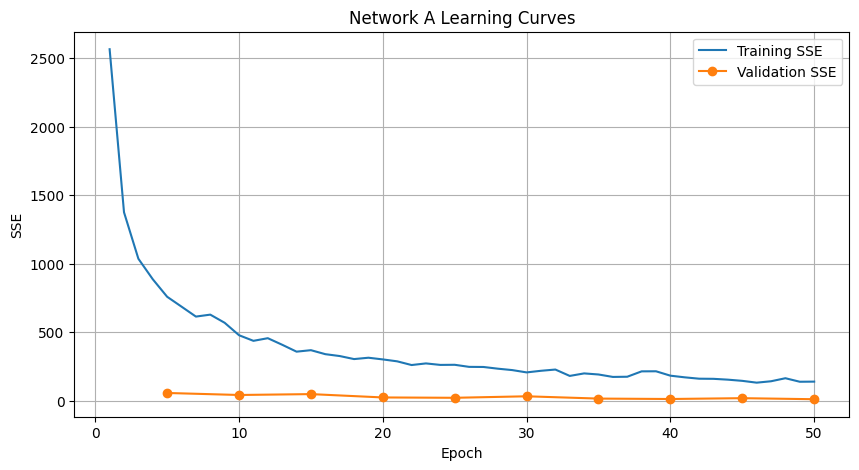

Confusion matrix:
 [[ 97   1   0   0   0   0   0   2]
 [  0  99   0   0   0   1   0   0]
 [  0   0 100   0   0   0   0   0]
 [  0   0   0 100   0   0   0   0]
 [  0   0   0   0 100   0   0   0]
 [  0   0   0   0   0 100   0   0]
 [  0   0   0   0   0   0 100   0]
 [  2   0   0   3   0   3   0  92]]


In [36]:
# Instruction 6: train Network A baseline

network_a = MLP2Hidden(
    input_dim=354,
    hidden1_dim=128,
    hidden2_dim=64,
    output_dim=8,
    act_h1="tanh",
    act_h2="tanh",
    act_out="logistic",
    act_h1_params={"a": 1.716, "b": 2/3},
    act_h2_params={"a": 1.716, "b": 2/3},
    act_out_params={"a": 2.0},
    seed=42
)

results_a = train_model(
    model=network_a,
    X_train=X_train,
    y_train_oh=y_train_oh,
    X_val=X_val,
    y_val_oh=y_val_oh,
    y_val_labels=y_val,
    epochs=50,
    batch_size=8,   # default from assignment
    lr=0.01,
    alpha=0.9,
    seed=42,
    prefix="network_a_baseline"
)

print("Training time (sec):", results_a["training_time_sec"])
print("Metrics:", results_a["metrics"])
plot_learning_curves(
    results_a["train_sse_history"],
    results_a["val_eval_history"],
    title="Network A Learning Curves"
)
print("Confusion matrix:\n", results_a["confusion_matrix"])

In [37]:
# Instruction 7: hyperparameter tuning for Network A

hidden_options = [
    (64, 32),
    (128, 64),
    (128, 128),
    (256, 128)
]

lr_options = [0.001, 0.005, 0.01, 0.05]
alpha_options = [0.8, 0.9, 0.95]

tuning_results_a = []

for h1, h2 in hidden_options:
    for lr in lr_options:
        for alpha in alpha_options:
            print(f"\nTraining Network A with h1={h1}, h2={h2}, lr={lr}, alpha={alpha}")

            model = MLP2Hidden(
                input_dim=354,
                hidden1_dim=h1,
                hidden2_dim=h2,
                output_dim=8,
                act_h1="tanh",
                act_h2="tanh",
                act_out="logistic",
                act_h1_params={"a": 1.716, "b": 2/3},
                act_h2_params={"a": 1.716, "b": 2/3},
                act_out_params={"a": 2.0},
                seed=42
            )

            res = train_model(
                model=model,
                X_train=X_train,
                y_train_oh=y_train_oh,
                X_val=X_val,
                y_val_oh=y_val_oh,
                y_val_labels=y_val,
                epochs=30,          # shorter for tuning
                batch_size=8,
                lr=lr,
                alpha=alpha,
                seed=42,
                prefix=f"tmp_a_h1_{h1}_h2_{h2}_lr_{str(lr).replace('.', '_')}_a_{str(alpha).replace('.', '_')}"
            )

            # use last validation SSE and misclassifications
            last_val = res["val_eval_history"][-1]
            tuning_results_a.append({
                "h1": h1,
                "h2": h2,
                "lr": lr,
                "alpha": alpha,
                "final_val_sse": float(last_val[1]),
                "final_miscls": int(last_val[2]),
                "train_time_sec": res["training_time_sec"]
            })

# sort best by validation SSE then misclassifications
tuning_results_a = sorted(tuning_results_a, key=lambda d: (d["final_val_sse"], d["final_miscls"]))

print("Top 10 Network A configs:")
for row in tuning_results_a[:10]:
    print(row)


Training Network A with h1=64, h2=32, lr=0.001, alpha=0.8
1/30 train_sse=3785.9026
2/30 train_sse=3498.2312
3/30 train_sse=3310.5301
4/30 train_sse=3130.8019
5/30 train_sse=2952.9832 val_sse=272.2728 miscls=353
6/30 train_sse=2783.2151
7/30 train_sse=2632.0128
8/30 train_sse=2501.5527
9/30 train_sse=2382.7333
10/30 train_sse=2274.5885 val_sse=209.6284 miscls=218
11/30 train_sse=2173.2008
12/30 train_sse=2080.1289
13/30 train_sse=1993.3595
14/30 train_sse=1914.4063
15/30 train_sse=1841.9154 val_sse=171.0326 miscls=177
16/30 train_sse=1778.0752
17/30 train_sse=1717.4133
18/30 train_sse=1661.1778
19/30 train_sse=1607.1342
20/30 train_sse=1556.7971 val_sse=144.1925 miscls=125
21/30 train_sse=1504.9896
22/30 train_sse=1456.6873
23/30 train_sse=1408.8300
24/30 train_sse=1363.9454
25/30 train_sse=1320.1955 val_sse=122.3292 miscls=111
26/30 train_sse=1276.4906
27/30 train_sse=1236.8320
28/30 train_sse=1197.0765
29/30 train_sse=1159.4552
30/30 train_sse=1125.0484 val_sse=103.8934 miscls=82

Tr